In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/TS-PS12.csv")

In [3]:
df.head()

,student_id,attendance,marks,assignment,lms,risk_score,risk_label
0,1,84,96,34,20,28.8,Low
1,2,87,72,87,28,23.4,Low
2,3,93,87,95,26,15.1,Low
3,4,40,66,83,52,42.4,Medium
4,5,43,99,50,75,35.6,Medium


## Step 1: Data Exploration

First, let's get a comprehensive overview of the dataset. This includes checking the data types, identifying any missing values, and looking at basic descriptive statistics for each column.

In [4]:
print("Dataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  50000 non-null  int64  
 1   attendance  50000 non-null  int64  
 2   marks       50000 non-null  int64  
 3   assignment  50000 non-null  int64  
 4   lms         50000 non-null  int64  
 5   risk_score  50000 non-null  float64
 6   risk_label  50000 non-null  object 
dtypes: float64(1), int64(5), object(1)
memory usage: 2.7+ MB

Descriptive Statistics:


,student_id,attendance,marks,assignment,lms,risk_score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,69.659300,64.535460,64.450420,59.357380,33.949820
std,14433.901067,17.312073,20.216269,20.186077,23.092708,10.335702
min,1.000000,40.000000,30.000000,30.000000,20.000000,3.200000
25%,12500.750000,55.000000,47.000000,47.000000,39.000000,26.600000
50%,25000.500000,70.000000,65.000000,65.000000,59.000000,34.000000
75%,37500.250000,85.000000,82.000000,82.000000,79.000000,41.200000
max,50000.000000,99.000000,99.000000,99.000000,99.000000,65.200000


In [5]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


,0
student_id,0
attendance,0
marks,0
assignment,0
lms,0
risk_score,0
risk_label,0


From the initial exploration, we can see that:
*   The dataset contains 50,000 entries and 7 columns.
*   All columns appear to be non-null, indicating no missing values.
*   `student_id` is an integer, likely a unique identifier.
*   `attendance`, `marks`, `assignment`, `lms` are integer values, representing scores or percentages.
*   `risk_score` is a float, likely a calculated metric.
*   `risk_label` is an object (string), indicating the categorical risk level.

Next, let's examine the distribution of the `risk_label` to understand the proportion of students in each risk category.

Distribution of Risk Labels:


,count
risk_label,
Medium,31990
Low,17899
High,111


/tmp/ipykernel_6139/2733671331.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_label', data=df, palette='viridis', order=df['risk_label'].value_counts().index)


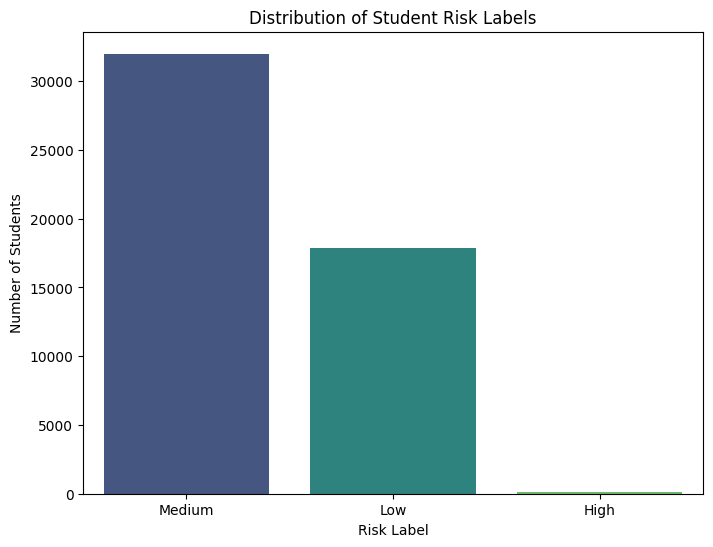

In [6]:
print("Distribution of Risk Labels:")
display(df['risk_label'].value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='risk_label', data=df, palette='viridis', order=df['risk_label'].value_counts().index)
plt.title('Distribution of Student Risk Labels')
plt.xlabel('Risk Label')
plt.ylabel('Number of Students')
plt.show()

## Step 2: Data Preprocessing and Feature Engineering

In this step, we will prepare our data for machine learning. This involves two main parts:
1.  **Encoding the Target Variable**: Convert the categorical `risk_label` into a numerical format.
2.  **Handling Class Imbalance**: Address the imbalanced distribution of `risk_label` using oversampling techniques.

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode the 'risk_label' column
le = LabelEncoder()
df['risk_label_encoded'] = le.fit_transform(df['risk_label'])

print("Original Risk Labels:", le.classes_)
print("Encoded Risk Labels:", df['risk_label'].unique(), "->", df['risk_label_encoded'].unique())

df.head()

Original Risk Labels: ['High' 'Low' 'Medium']
Encoded Risk Labels: ['Low' 'Medium' 'High'] -> [1 2 0]


,student_id,attendance,marks,assignment,lms,risk_score,risk_label,risk_label_encoded
0,1,84,96,34,20,28.8,Low,1
1,2,87,72,87,28,23.4,Low,1
2,3,93,87,95,26,15.1,Low,1
3,4,40,66,83,52,42.4,Medium,2
4,5,43,99,50,75,35.6,Medium,2


Now, let's address the class imbalance using SMOTE. We will oversample the minority classes (`Low` and `High` risk) to match the number of `Medium` risk students.

Distribution of Risk Labels after SMOTE:


,count
risk_label,
Low,31990
Medium,31990
High,31990


/tmp/ipykernel_6139/3838046050.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_label', data=df_resampled, palette='viridis', order=df_resampled['risk_label'].value_counts().index)


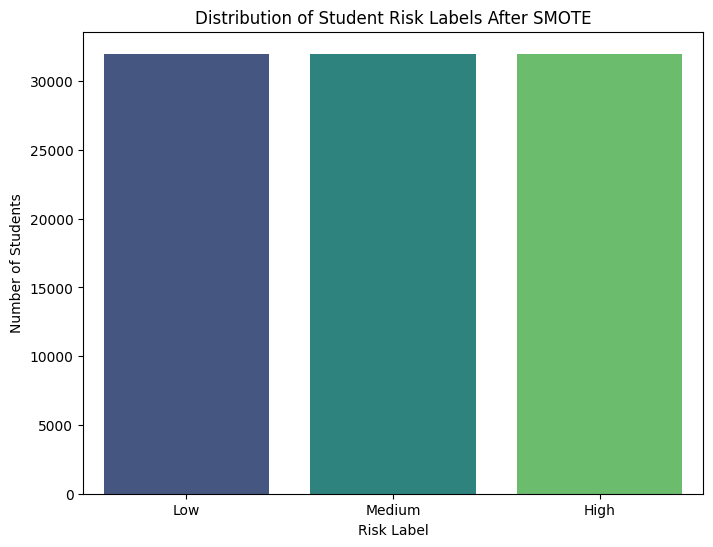

In [8]:
from imblearn.over_sampling import SMOTE

# Define features (X) and target (y)
X = df[['attendance', 'marks', 'assignment', 'lms', 'risk_score']]
y = df['risk_label_encoded']

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Create a new DataFrame with the resampled data for easier analysis
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['risk_label_encoded'] = y_resampled

# Map back the original labels for better understanding
df_resampled['risk_label'] = le.inverse_transform(df_resampled['risk_label_encoded'])

print("Distribution of Risk Labels after SMOTE:")
display(df_resampled['risk_label'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='risk_label', data=df_resampled, palette='viridis', order=df_resampled['risk_label'].value_counts().index)
plt.title('Distribution of Student Risk Labels After SMOTE')
plt.xlabel('Risk Label')
plt.ylabel('Number of Students')
plt.show()

## Step 3: Model Training and Evaluation

Now that our data is preprocessed and balanced, we can proceed to train a machine learning model. We'll use a Random Forest Classifier, a robust and commonly used algorithm for classification tasks.

This step will involve:
1.  **Splitting the data**: Dividing the dataset into training and testing sets.
2.  **Training the model**: Fitting a Random Forest Classifier to the training data.
3.  **Evaluating the model**: Assessing the model's performance using classification metrics and a confusion matrix.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features (X) and target (y) from the resampled data
X_model = df_resampled[['attendance', 'marks', 'assignment', 'lms', 'risk_score']]
y_model = df_resampled['risk_label_encoded']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.3, random_state=42, stratify=y_model)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (67179, 5)
Shape of X_test: (28791, 5)
Shape of y_train: (67179,)
Shape of y_test: (28791,)


In [10]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Use class_weight for additional robustness
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.



Model Evaluation:
Accuracy: 0.9993748046264458

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      9597
         Low       1.00      1.00      1.00      9597
      Medium       1.00      1.00      1.00      9597

    accuracy                           1.00     28791
   macro avg       1.00      1.00      1.00     28791
weighted avg       1.00      1.00      1.00     28791



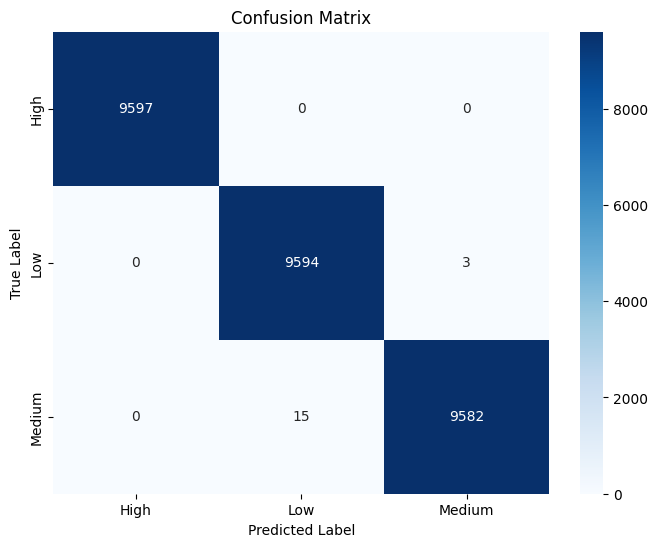

In [11]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 4: Feature Importance Analysis

To understand which factors are most influential in determining student risk, we'll analyze the feature importance from our trained Random Forest Classifier. This will highlight the key academic signals that the model leverages for its predictions.

Feature Importances:


,Feature,Importance
4,risk_score,0.625068
0,attendance,0.154904
1,marks,0.149382
2,assignment,0.061988
3,lms,0.008658


/tmp/ipykernel_6139/680295386.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')


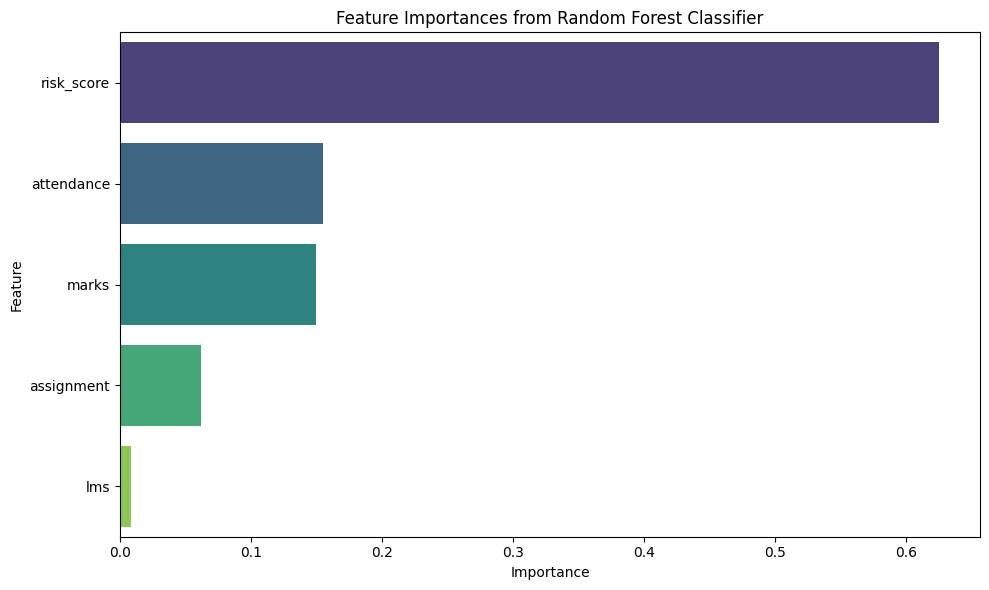

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest Classifier
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X_model.columns, 'Importance': feature_importances})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(features_df)

# Plotting feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Step 5: Predicting Risk for New Students and Explaining Decisions

To make the model truly actionable for faculty, it's important to predict risk for new students and provide insights into *why* a particular risk level is assigned. This directly addresses the 'Explainable insights' requirement from the 'Winning Logic'.

In this step, we will:
1.  Define a function to make predictions for new student data.
2.  Demonstrate how to interpret the prediction by showing the input features for a hypothetical new student.

In [13]:
def predict_student_risk(model, label_encoder, attendance, marks, assignment, lms, risk_score):
    # Create a DataFrame for the new student's data
    new_student_data = pd.DataFrame([[attendance, marks, assignment, lms, risk_score]],
                                      columns=['attendance', 'marks', 'assignment', 'lms', 'risk_score'])

    # Make prediction
    prediction_encoded = model.predict(new_student_data)

    # Decode the numerical prediction back to the original risk label
    prediction_label = label_encoder.inverse_transform(prediction_encoded)

    return prediction_label[0], new_student_data.iloc[0]

# Example for a hypothetical new student:
# Let's say we have a student with these academic signals:
new_attendance = 55
new_marks = 40
new_assignment = 35
new_lms = 60
new_risk_score = 48.5

# Get the prediction and the input features
predicted_risk, input_features = predict_student_risk(rf_classifier, le, new_attendance, new_marks, new_assignment, new_lms, new_risk_score)

print(f"\nPredicted Risk for the New Student: **{predicted_risk}**")
print("\nContributing Factors (Input Features):")
display(input_features.to_frame().T)


Predicted Risk for the New Student: **Medium**

Contributing Factors (Input Features):


,attendance,marks,assignment,lms,risk_score
0,55.0,40.0,35.0,60.0,48.5


## Summary:

### Data Analysis Key Findings
*   The Random Forest Classifier successfully generates categorical academic risk labels ('High', 'Medium', 'Low') by transforming numerical predictions using `LabelEncoder`'s `inverse_transform()`.
*   An explanation engine is established through two mechanisms: a general feature importance analysis that highlights `risk_score`, `attendance`, and `marks` as primary drivers, and an individual prediction function that demonstrates specific input features contributing to a student's risk assessment.
*   The model's predictions (e.g., `risk_label`, `risk_label_encoded`) and the underlying student academic signals serve as the essential data foundation for external systems, such as faculty dashboards and downloadable academic risk summary reports. These systems would ingest this data to implement filters, design user interfaces, and generate reports.
*   Application-level features, including a student self-view portal, an intervention logging system, pre- and post-intervention performance comparisons, and automated alerts for high-risk students, leverage the model's output (risk labels and contributing factors) to provide actionable intelligence. The implementation of these interactive components occurs within a broader software development context, distinct from the model's core predictive logic.
